In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
import random
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from skimage.feature import hog
from sklearn.svm import LinearSVC
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.svm import SVC
from utils.Hog import HoG, calc_gradients, predict_char

In [ ]:
IMG_SIZE = 128
images_folder = '../data/OCR/digital_chars'
folders = os.listdir(images_folder)
x_features = []
y_label = []
count = 0
for folder in folders:
    folder_path = os.path.join(images_folder, folder)
    label = folder.split('_')[0]
    print(f"Processing folder: {label}")
    for image_name in os.listdir(folder_path):
        count += 1
        print(f"Processing image: {count}")
        image_path = os.path.join(folder_path, image_name)
        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
        image = image.astype(np.float32) / 255.0
        magnitudes, orientations = calc_gradients(image)
        features = HoG(orientations, magnitudes, cell_size=16, num_bins=9, block_size=2)
        # features = hog(image, orientations=9, pixels_per_cell=(16, 16), cells_per_block=(2, 2), block_norm='L2-Hys')
        x_features.append(features)
        y_label.append(label)


['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'a_lower', 'A_upper', 'b_lower', 'B_upper', 'C_upper', 'd_lower', 'D_upper', 'e_lower', 'E_upper', 'f_lower', 'F_upper', 'g_lower', 'G_upper', 'h_lower', 'H_upper', 'I_upper', 'J_upper', 'K_upper', 'L_upper', 'M_upper', 'n_lower', 'N_upper', 'O_upper', 'P_upper', 'q_lower', 'Q_upper', 'r_lower', 'R_upper', 'S_upper', 't_lower', 'T_upper', 'U_upper', 'V_upper', 'W_upper', 'X_upper', 'Y_upper', 'Z_upper']


In [7]:
x = np.array(x_features)
y = np.array(y_label)
print("Feature shape:", x.shape)
print("Label shape:", y.shape)
print("Unique labels:", np.unique(y))

Feature shape: (62992, 1764)
Label shape: (62992,)
Unique labels: ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9' 'A' 'B' 'C' 'D' 'E' 'F' 'G' 'H'
 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R' 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z'
 'a' 'b' 'd' 'e' 'f' 'g' 'h' 'n' 'q' 'r' 't']


In [ ]:
joblib.dump(x, './features/x_features_hog.joblib')
joblib.dump(y, './features/y_labels_hog.joblib')

['y_labels_hog.joblib']

In [ ]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)
train_x, test_x, train_y, test_y = train_test_split(x, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

In [ ]:
joblib.dump(le, './models/ready_made_SVM/label_encoder.joblib')

In [ ]:
model = LinearSVC(random_state=42, max_iter=10000, C = 2.0, class_weight='balanced')
# model = SVC(
#     kernel='linear',
#     probability=True,
#     C=2.0,
#     class_weight='balanced',
#     random_state=42
# )
model.fit(train_x, train_y)

LinearSVC(C=2.0, class_weight='balanced', max_iter=10000, random_state=42)

In [ ]:
joblib.dump(model, './models/ready_made_SVM/scikit_SVM.joblib')

['hog_manual_svm_model.joblib']

In [10]:
predictions = model.predict(test_x)
F1 = f1_score(test_y, predictions, average='weighted')
print("F1 Score:", F1)

F1 Score: 0.9521827622429071


In [12]:
def predict(image):
    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
    image = image.astype(np.float32) / 255.0
    magnitudes, orientations = calc_gradients(image)
    # test_features = HoG(orientations, magnitudes, cell_size=16, num_bins=9, block_size=2).reshape(1, -1)
    magnitudes, orientations = calc_gradients(image)
    test_features = HoG(orientations, magnitudes, cell_size=16, num_bins=9, block_size=2).reshape(1, -1)
    predicted_label = model.predict(test_features)
    print("Predicted label for test image:", le.inverse_transform(predicted_label)[0])

Predicted label for test image: A


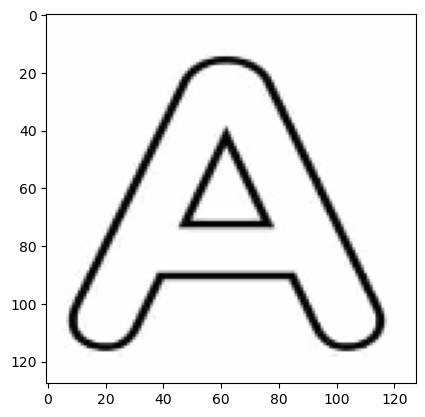

In [21]:
image = cv2.imread('test.jpeg', cv2.IMREAD_GRAYSCALE)
image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
plt.imshow(image, cmap='gray')
predict(image)